# Smart Waste Management using AI

This notebook demonstrates waste detection using a YOLO-based model along with basic data analysis.

In [9]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

## Dataset Overview

The dataset consists of images of garbage such as plastic, paper, and waste materials.

- Type: Image Dataset  
- Source: Custom dataset  
- Classes: Garbage  

In [10]:
import os

image_folder = "GarbageDetector/media"

data = []

for img_name in os.listdir(image_folder):
    path = os.path.join(image_folder, img_name)
    img = cv2.imread(path)

    if img is not None:
        h, w, _ = img.shape
        data.append({
            "image": img_name,
            "width": w,
            "height": h,
            "size": w * h
        })

df = pd.DataFrame(data)
df.head()

,image,width,height,size
0,garbage_1.jpg,720,480,345600
1,garbage_2.jpg,612,407,249084
2,garbage_3.jpeg,720,480,345600
3,garbage_4.jpg,720,480,345600
4,garbage_5.jpeg,720,540,388800


In [11]:
print(df.describe())

            width       height          size
count    7.000000     7.000000  7.000000e+00
mean   710.000000   597.857143  4.468743e+05
std     85.580372   352.368381  3.378826e+05
min    612.000000   407.000000  2.490840e+05
25%    666.000000   444.000000  2.976480e+05
50%    720.000000   480.000000  3.456000e+05
75%    720.000000   510.000000  3.672000e+05
max    866.000000  1390.000000  1.203740e+06


EDA helps in understanding image properties such as size and resolution, which may affect model performance.

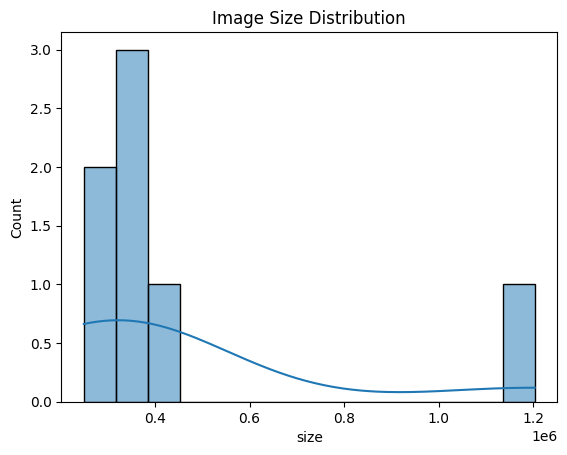

In [12]:
sns.histplot(df["size"], kde=True)
plt.title("Image Size Distribution")
plt.show()

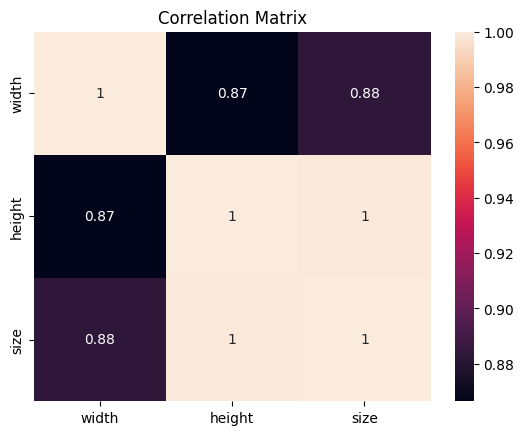

In [14]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [15]:
model = YOLO("GarbageDetector/weights/best1.pt")

In [23]:
img = cv2.imread("GarbageDetector/media/garbage_5.jpeg")

results = model(img)

for r in results:
    print("Detected:", len(r.boxes))


0: 480x640 4 garbages, 371.1ms
Speed: 37.6ms preprocess, 371.1ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Detected: 4



0: 480x640 4 garbages, 314.1ms
Speed: 1.5ms preprocess, 314.1ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


(np.float64(-0.5), np.float64(719.5), np.float64(539.5), np.float64(-0.5))

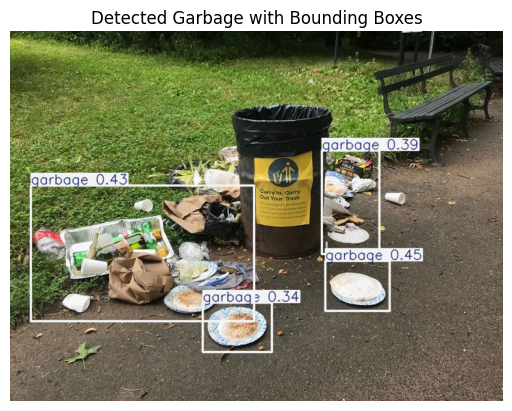

In [24]:
results = model(img)

# Get plotted image (with boxes)
annotated_img = results[0].plot()

# Show image
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Garbage with Bounding Boxes")
plt.axis("off")

## Conclusion

The YOLO model successfully detects garbage in images using bounding boxes and labels.  
EDA helps analyze dataset characteristics such as image size.  
This system can be extended for real-time smart waste management applications.